In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("sales_data.csv")

df.head()

,Date,Region,Product,Category,Units_Sold,Unit_Price
0,2024-01-01,North,Laptop,Electronics,5,800
1,2024-01-02,South,Phone,Electronics,10,500
2,2024-01-03,East,Tablet,Electronics,7,300
3,2024-01-04,West,Headphones,Accessories,15,50
4,2024-01-05,North,Monitor,Electronics,6,200


In [4]:
df['Date'] = pd.to_datetime(df['Date'])

df['Revenue'] = df['Units_Sold'] * df['Unit_Price']

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        10 non-null     datetime64[ns]
 1   Region      10 non-null     object        
 2   Product     10 non-null     object        
 3   Category    10 non-null     object        
 4   Units_Sold  10 non-null     int64         
 5   Unit_Price  10 non-null     int64         
 6   Revenue     10 non-null     int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 692.0+ bytes


In [5]:
total_revenue = df['Revenue'].sum()
total_units = df['Units_Sold'].sum()
avg_order_value = df['Revenue'].mean()

print("Total Revenue:", total_revenue)
print("Total Units Sold:", total_units)
print("Average Order Value:", avg_order_value)

Total Revenue: 23350
Total Units Sold: 106
Average Order Value: 2335.0


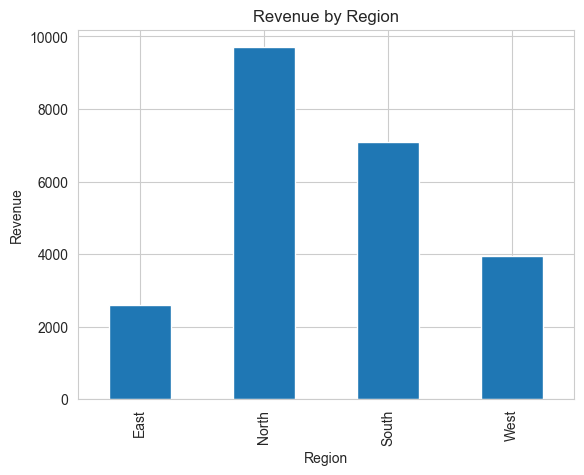

In [6]:
region_sales = df.groupby('Region')['Revenue'].sum()

region_sales.plot(kind='bar')
plt.title("Revenue by Region")
plt.ylabel("Revenue")
plt.show()

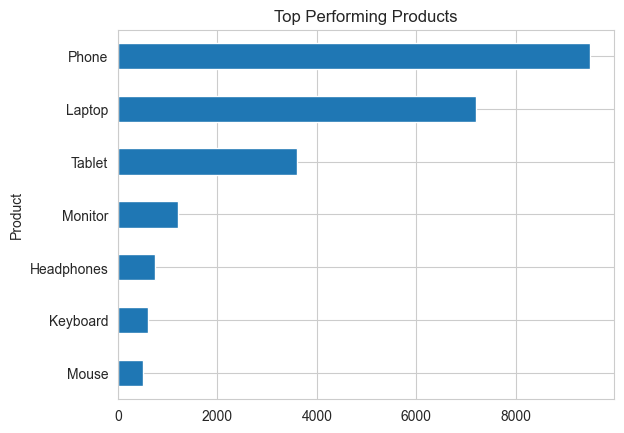

In [7]:
product_sales = df.groupby('Product')['Revenue'].sum().sort_values()

product_sales.plot(kind='barh')
plt.title("Top Performing Products")
plt.show()

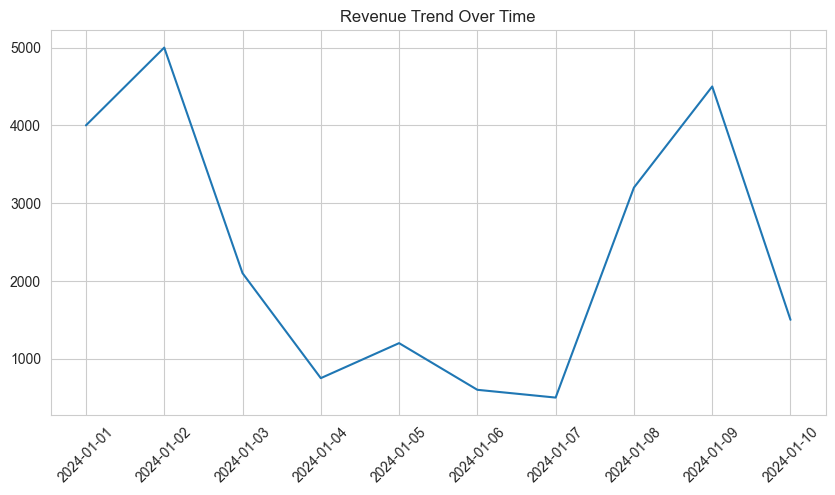

In [8]:
monthly_sales = df.groupby(df['Date'].dt.date)['Revenue'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales)
plt.title("Revenue Trend Over Time")
plt.xticks(rotation=45)
plt.show()

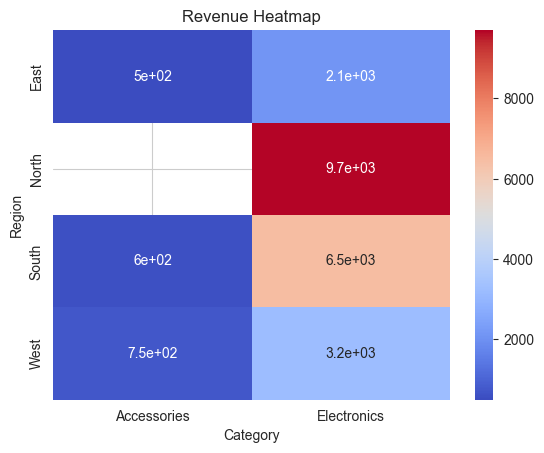

In [9]:
pivot = df.pivot_table(values='Revenue',
                       index='Region',
                       columns='Category',
                       aggfunc='sum')

sns.heatmap(pivot, annot=True, cmap='coolwarm')

plt.title("Revenue Heatmap")
plt.show()